Use version Python 3.11.3

In [ ]:
import torch
import torch.nn as nn
import torchvision.transforms as transforms
from torchvision import models
from torchvision.io import decode_image
from torch.utils.data import DataLoader
from torch.optim.lr_scheduler import ReduceLROnPlateau
from tqdm import tqdm
import numpy as np
import matplotlib.pyplot as plt
from skimage import io, transform
from sklearn import metrics
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split, StratifiedKFold, KFold, cross_val_score
from sklearn.ensemble import RandomForestClassifier
import lightgbm as lgb
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.experimental import enable_halving_search_cv
from PIL import Image, ImageEnhance
import pandas as pd
import os
from catboost import CatBoostClassifier
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
from torchvision import datasets, models
from torchvision.io import decode_image
from torch.utils.data import DataLoader
from torch.optim.lr_scheduler import ReduceLROnPlateau
from tqdm import tqdm

### Data Loading

In [ ]:
# # Create train and test sets
# train_size = 0.8
# test_size = 0.2

# dataset_labels_file = '../../data/training/training_dataset_labels_wo_manual_review.csv'
# dataset_labels = pd.read_csv(dataset_labels_file).dropna(subset=['best_tool'])

# number_of_classes = dict()
# for label_class in dataset_labels['best_tool'].unique():
#     number_of_classes[label_class] = len(dataset_labels[dataset_labels['best_tool'] == label_class])
# print("Number of classes:", number_of_classes)
# majority_class = max(number_of_classes, key=number_of_classes.get)
# majority_class_count = number_of_classes[majority_class]
# minority_class = min(number_of_classes, key=number_of_classes.get)
# minority_class_count = number_of_classes[minority_class]
# if majority_class_count != minority_class_count:
#     print(f"Class imbalance detected! The majority class will be downsampled to the size of the minority class.")
#     diff_count = majority_class_count - minority_class_count
#     dataset_labels_major = dataset_labels[dataset_labels['best_tool'] == majority_class].sample(n=diff_count, random_state=42)
#     dataset_labels = dataset_labels.drop(dataset_labels_major.index)
#     print(f"Downsampling successful! New class distrbution: {dataset_labels['best_tool'].value_counts()}")
# else:
#     print("No class imbalance detected. Proceed...")

# label_encoder = LabelEncoder()
# dataset_labels['best_tool_encoded'] = label_encoder.fit_transform(dataset_labels['best_tool'])
# label_mapping = {index: label for index, label in enumerate(label_encoder.classes_)}
# print("Label Mapping:", label_mapping)

# train_df, test_df = train_test_split(dataset_labels, test_size=test_size, random_state=42, stratify=dataset_labels['best_tool_encoded'])

Number of classes: {'vouchervision': 962, 'herbonauten': 437}
Class imbalance detected! The majority class will be downsampled to the size of the minority class.
Downsampling successful! New class distrbution: best_tool
herbonauten      437
vouchervision    437
Name: count, dtype: int64
Label Mapping: {0: 'herbonauten', 1: 'vouchervision'}


In [ ]:
# # save the train and test sets as well as the label mapping to CSV or TXT files 
# train_df.to_csv('../../data/training/train_set.csv', index=False)
# test_df.to_csv('../../data/training/test_set.csv', index=False)

# with open('../../data/training/label_mapping.txt', 'w') as f:
#     for label, num in label_mapping.items():
#         f.write(f"{label}\t{num}\n")

In [2]:
test_features_handcrafted = pd.read_csv('../../data/training/test_set_features.csv') # Input features tabular ML models
label_encoder = LabelEncoder()
labels = pd.read_csv('../../data/training/test_set.csv')[['best_tool']].dropna() # Target labels
labels['best_tool_encoded'] = label_encoder.fit_transform(labels['best_tool'])
label_mapping = dict()
for index, label in enumerate(label_encoder.classes_):
    label_mapping[index] = label
print("Label Mapping:", label_mapping)
test_df_target = test_features_handcrafted[['catalogNumber', 'best_tool_encoded']].set_index('catalogNumber') # Target labels
test_features_handcrafted = test_features_handcrafted.set_index('catalogNumber').drop(columns=['best_tool_encoded'])

Label Mapping: {0: 'herbonauten', 1: 'vouchervision'}


In [4]:
predictions_df = test_df_target.reset_index()[['catalogNumber']].copy() # DataFrame for storing predictions from the models applied
predictions_df['predicted_label_pipeline_tab'] = np.nan
predictions_df['predicted_label_pipeline_cnn'] = np.nan
predictions_df['predicted_label_pipeline_hybrid'] = np.nan
predictions_df['predicted_label_pipeline_weight_factor'] = np.nan
predictions_df.to_csv('../../data/predictions/prediction.csv', index=False)

In [ ]:
# # Prepare the training and test data and labels
# x_train = train_df.drop(columns=['best_tool', 'best_tool_encoded'])
# y_train = train_df['best_tool_encoded']
# x_test = test_df.drop(columns=['best_tool', 'best_tool_encoded'])
# y_test = test_df['best_tool_encoded']

### ML Handcrafted Features Pipeline

In [ ]:
# # Prepare the feature data for training and evaluation
# df_handcrafted = pd.read_csv('../../data/features/extracted_handcrafted_features.csv', index_col=0)
# df_handcrafted['catalogNumber'] = df_handcrafted.index.str.split("/").str[-1].str.split(".").str[0]
# df_label_features = pd.read_csv('../../data/features/label_features_normalized.csv', index_col=0)
# df_label_features['catalogNumber'] = df_label_features.index.str.split("/").str[-1].str.split(".").str[0]
# df_features = df_handcrafted.merge(df_label_features, on='catalogNumber', how='inner')
# labels = pd.read_csv('../../data/training/training_dataset_labels_wo_manual_review.csv')
# labels = labels.dropna(subset=['best_tool'])

# df_features_labels = df_features.merge(labels[['catalogNumber', 'best_tool']], on='catalogNumber', how='inner')
# df_features_labels['best_tool_encoded'] = label_encoder.transform(df_features_labels['best_tool'])
# df_features_labels = df_features_labels.drop(columns=['best_tool'])
# df_features_labels = df_features_labels.set_index('catalogNumber')
# x_train_handcrafted = df_features_labels.loc[train_df['catalogNumber']].drop(columns=['best_tool_encoded'])
# y_train_handcrafted = df_features_labels.loc[train_df['catalogNumber'], 'best_tool_encoded']
# x_test_handcrafted = df_features_labels.loc[test_df['catalogNumber']].drop(columns=['best_tool_encoded'])
# y_test_handcrafted = df_features_labels.loc[test_df['catalogNumber'], 'best_tool_encoded']
# x_train_handcrafted

,mean_conf,min_conf,std_conf,words_count,char_count,num_text_lines,num_text_blocks,low_conf_ratio,text_density,handwriting_ocr,...,noise_sigma,background_uniformity,overlapped_label_area,detected_lang_encoded,number_of_labels,mean_label_width,mean_label_height,label_spread,areas,handwritten_flag
catalogNumber,,,,,,,,,,,,,,,,,,,,,
B101124874,0.840970,0.000000,0.514388,0.065882,0.057959,0.172414,0.24,0.142857,0.293526,0.0,...,1.778138e-01,0.360342,0.234042,0.230769,0.333333,0.544493,0.338005,0.000000,0.200154,0.0
B101196568,0.774390,0.000000,0.620270,0.115294,0.107518,0.224138,0.28,0.204082,0.478689,0.0,...,1.836269e-01,0.399135,0.003575,0.192308,0.666667,0.523789,0.350783,0.315253,0.399506,0.0
B101066249,0.503623,0.000000,0.760942,0.063529,0.048719,0.103448,0.20,0.592593,0.126885,1.0,...,3.489153e-01,0.477973,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0
B101184334,0.511357,0.000000,0.680976,0.103529,0.070559,0.241379,0.36,0.500000,0.240564,1.0,...,1.619321e-01,0.113449,0.005670,0.230769,0.333333,0.569163,0.227535,0.000000,0.140843,0.0
B101124855,0.862051,0.000000,0.497913,0.209412,0.192776,0.448276,0.64,0.134831,0.232219,0.0,...,2.337289e-01,0.184148,0.000000,0.230769,0.333333,0.540969,0.464963,0.000000,0.273552,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
B100699729,0.453615,0.000000,0.622234,0.077647,0.061739,0.137931,0.20,0.606061,0.336942,1.0,...,1.185426e-01,0.310954,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0
B100030420,0.897543,0.108933,0.386011,0.280000,0.264175,0.379310,0.56,0.084034,0.240282,0.0,...,8.501196e-15,0.392017,0.000000,0.230769,0.333333,0.323348,0.504534,0.000000,0.177423,0.0
B101039277,0.537205,0.000000,0.727185,0.098824,0.062159,0.327586,0.20,0.523810,0.336331,0.0,...,3.021695e-01,0.401936,0.000000,1.000000,0.333333,0.529515,0.300907,0.000000,0.173284,0.0


Max F1-score for RF model: 0.8066 for class 'herbonauten'
Classificati on Report for Random Forest Classifier:
                precision    recall  f1-score   support

  herbonauten       0.78      0.83      0.81        88
vouchervision       0.82      0.77      0.79        87

     accuracy                           0.80       175
    macro avg       0.80      0.80      0.80       175
 weighted avg       0.80      0.80      0.80       175



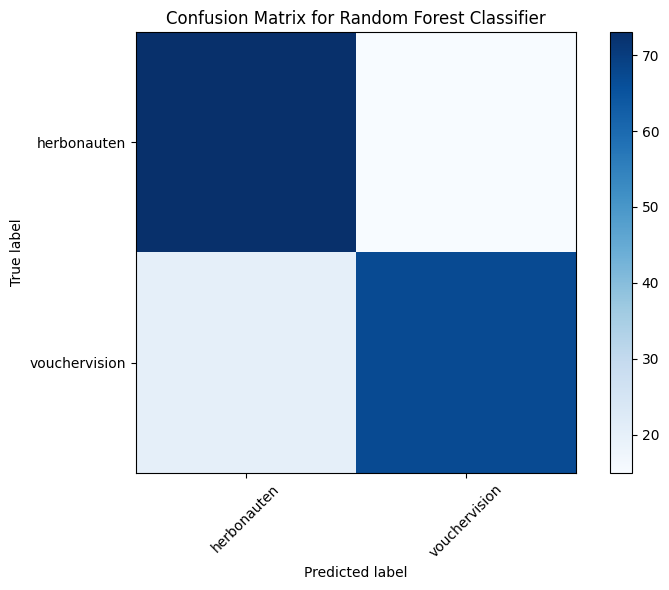

In [ ]:
# RF model evaluation
rf_model = pd.read_pickle('../../models/tabular/best_rf_classifier_grid.pkl')
pred_rf_proba = rf_model.predict_proba(test_features_handcrafted) # predict probabilities for all classes
pred_rf_labels = rf_model.predict(test_features_handcrafted) # predict class labels
cr = classification_report(test_df_target['best_tool_encoded'], pred_rf_labels, target_names=label_mapping.values())
# print max f1-score for RF model
report_dict_rf = classification_report(test_df_target['best_tool_encoded'], pred_rf_labels, target_names=label_mapping.values(), output_dict=True)
f1_scores_rf = {label: report_dict_rf[label]['f1-score'] for label in label_mapping.values()}
max_f1_label_rf = max(f1_scores_rf, key=f1_scores_rf.get)
print(f"Max F1-score for RF model: {f1_scores_rf[max_f1_label_rf]:.4f} for class '{max_f1_label_rf}'")
print("Classificati on Report for Random Forest Classifier:\n", cr)
cm = confusion_matrix(test_df_target['best_tool_encoded'], pred_rf_labels)
plt.figure(figsize=(8, 6))
plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
plt.title('Confusion Matrix for Random Forest Classifier')
plt.colorbar()
tick_marks = np.arange(len(label_mapping))
plt.xticks(tick_marks, label_mapping.values(), rotation=45)
plt.yticks(tick_marks, label_mapping.values())
plt.ylabel('True label')
plt.xlabel('Predicted label')
plt.tight_layout()
plt.show()

pred_rf_proba = pred_rf_proba[:, 1] # get probabilities for VoucherVision class
rf_predictions = {catalog: pred for catalog, pred in zip(test_df_target.reset_index()['catalogNumber'], pred_rf_labels.tolist())}

Max F1-score for LightGBM model: 0.8136 for class 'herbonauten'
Classification Report for LightGBM Classifier:
                precision    recall  f1-score   support

  herbonauten       0.81      0.82      0.81        88
vouchervision       0.81      0.80      0.81        87

     accuracy                           0.81       175
    macro avg       0.81      0.81      0.81       175
 weighted avg       0.81      0.81      0.81       175



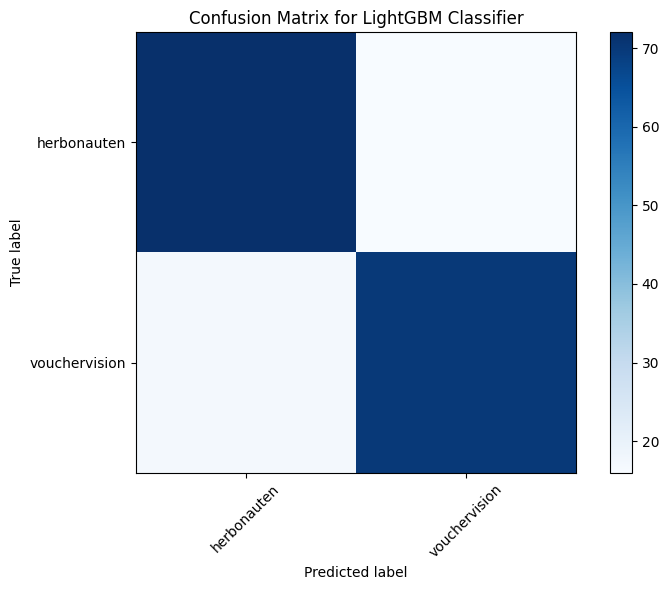

In [ ]:
# LightGBM model evaluation
lgb_model = pd.read_pickle('../../models/tabular/best_LightGBM_grid.pkl')
pred_lgb_proba = lgb_model.predict_proba(test_features_handcrafted)
pred_lgb_labels = lgb_model.predict(test_features_handcrafted)
cr = classification_report(test_df_target['best_tool_encoded'], pred_lgb_labels, target_names=label_mapping.values())
report_dict_lgb = classification_report(test_df_target['best_tool_encoded'], pred_lgb_labels, target_names=label_mapping.values(), output_dict=True)
f1_scores_lgb = {label: report_dict_lgb[label]['f1-score'] for label in label_mapping.values()}
max_f1_label_lgb = max(f1_scores_lgb, key=f1_scores_lgb.get)
print(f"Max F1-score for LightGBM model: {f1_scores_lgb[max_f1_label_lgb]:.4f} for class '{max_f1_label_lgb}'")
print("Classification Report for LightGBM Classifier:\n", cr)
cm = confusion_matrix(test_df_target['best_tool_encoded'], pred_lgb_labels)
plt.figure(figsize=(8, 6))
plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
plt.title('Confusion Matrix for LightGBM Classifier')
plt.colorbar()
tick_marks = np.arange(len(label_mapping))
plt.xticks(tick_marks, label_mapping.values(), rotation=45)
plt.yticks(tick_marks, label_mapping.values())
plt.ylabel('True label')
plt.xlabel('Predicted label')
plt.tight_layout()
plt.show()

pred_lgb_proba = pred_lgb_proba[:, 1] # get probabilities for the VoucherVision class
lgb_predictions = {catalog: pred for catalog, pred in zip(test_df_target.reset_index()['catalogNumber'], pred_lgb_labels.tolist())}

Max F1-score for SVC model: 0.7821 for class 'vouchervision'
Classification Report for SVC Classifier:
                precision    recall  f1-score   support

  herbonauten       0.80      0.75      0.77        88
vouchervision       0.76      0.80      0.78        87

     accuracy                           0.78       175
    macro avg       0.78      0.78      0.78       175
 weighted avg       0.78      0.78      0.78       175



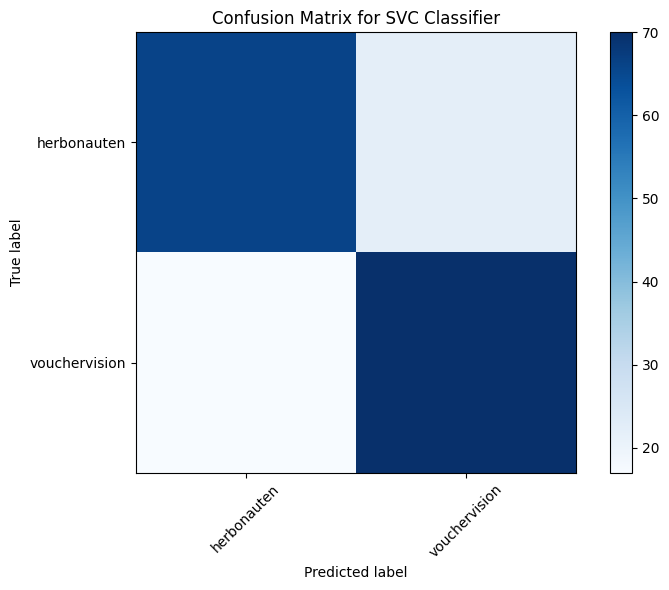

In [ ]:
# SVC model evaluation
svc_model = pd.read_pickle('../../models/tabular/best_SVC_grid.pkl')
pred_svc_proba = svc_model.predict_proba(test_features_handcrafted) # get decision function scores for SVC
pred_svc_labels = svc_model.predict(test_features_handcrafted)
cr = classification_report(test_df_target['best_tool_encoded'], pred_svc_labels, target_names=label_mapping.values())
report_dict_svc = classification_report(test_df_target['best_tool_encoded'], pred_svc_labels, target_names=label_mapping.values(), output_dict=True)
f1_scores_svc = {label: report_dict_svc[label]['f1-score'] for label in label_mapping.values()}
max_f1_label_svc = max(f1_scores_svc, key=f1_scores_svc.get)
print(f"Max F1-score for SVC model: {f1_scores_svc[max_f1_label_svc]:.4f} for class '{max_f1_label_svc}'")
print("Classification Report for SVC Classifier:\n", cr)
cm = confusion_matrix(test_df_target['best_tool_encoded'], pred_svc_labels)
plt.figure(figsize=(8, 6))
plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
plt.title('Confusion Matrix for SVC Classifier')
plt.colorbar()
tick_marks = np.arange(len(label_mapping))
plt.xticks(tick_marks, label_mapping.values(), rotation=45)
plt.yticks(tick_marks, label_mapping.values())
plt.ylabel('True label')
plt.xlabel('Predicted label')
plt.tight_layout()
plt.show()
pred_svc_proba = pred_svc_proba[:, 1] # get probabilities for the VoucherVision class
svc_predictions = {catalog: pred for catalog, pred in zip(test_df_target.reset_index()['catalogNumber'], pred_svc_labels.tolist())}

### CNN Pipeline

In [ ]:
# CNN classifier pipeline
class HerbariumImagesDataset(torch.utils.data.Dataset):

    def __init__(self, df, image_path, transform=None):
        self.labels = self._load_labels(df)
        self.image_dir = image_path
        self.transform = transform
        self.image_bboxes = pd.read_csv('../../data/training/bounding_boxes.csv', index_col=0).to_dict(orient='index')

    def __len__(self):
        return len(self.labels)
    
    def __getitem__(self, index):
        image_name = self.labels.iloc[index, 0]
        image_path = os.path.join(self.image_dir, image_name + '.jpg')
        label = self.labels.iloc[index, 1]
        image = Image.open(image_path).convert('RGB')
        bbox = self.image_bboxes.get(image_name, None)
        if bbox:
            image = image.crop((bbox['x_min'], bbox['y_min'], bbox['x_max'], bbox['y_max']))
        else:
            image = image.crop((0, image.height // 2, image.width, image.height))
        if self.transform:
            image = self.transform(image)
        return image, label

    def _load_labels(self, df):
        df = df.copy()
        print(df['best_tool_encoded'].value_counts())
        return df[['catalogNumber', 'best_tool_encoded']]

test_transform = transforms.Compose([
    transforms.Resize((640, 640)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

test_dataset = HerbariumImagesDataset(test_df_target.reset_index()[['catalogNumber', 'best_tool_encoded']], '../../data/sample_images_stratified_after_filter/', transform=test_transform)

test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

model = models.efficientnet_b0(pretrained=True)
classes = 2
features = model.classifier[1].in_features 

model.classifier[1] = nn.Sequential(
    nn.Dropout(p=0.5, inplace=True),
    nn.Linear(features, classes),
    nn.Softmax(dim=1) # get probability outputs with softmax
)

for param in model.parameters():
    param.requires_grad = False

for param in model.features[6].parameters(): # efficientnet_b0, mobilenet_v2
# for param in model.layer4.parameters(): # skresnet18, resnet34
    param.requires_grad = True

for param in model.classifier[1].parameters(): # efficientnet_b0, mobilenet_v2
# for param in model.fc.parameters(): # skresnet18, resnet34
    param.requires_grad = True

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

best_tool_encoded
0    88
1    87
Name: count, dtype: int64


c:\Users\mernst\Nextcloud\Voucher classifier\master_thesis\notebooks\ml\.venv-ml\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\mernst\Nextcloud\Voucher classifier\master_thesis\notebooks\ml\.venv-ml\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=EfficientNet_B0_Weights.IMAGENET1K_V1`. You can also use `weights=EfficientNet_B0_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [193]:
model.load_state_dict(torch.load('../../models/final_best_model_EfficientNet_B0.pth', map_location=device))
model.eval()
y_pred_cnn = dict()
all_labels = []
all_preds = []
all_probs = []
with torch.no_grad():
    for inputs, labels in tqdm(test_loader):
        inputs = inputs.to(device).float()
        labels = labels.to(device).long()
        outputs = model(inputs)
        prob_cnn = torch.nn.Softmax(dim=1)(outputs)[:, 1].cpu().numpy() # get probability of class 1 (positive class)
        all_probs.extend(prob_cnn)
        _, predicted = torch.max(outputs, 1)
        all_labels.extend(labels.cpu().numpy())
        all_preds.extend(predicted.cpu().numpy())
cm = confusion_matrix(all_labels, all_preds)
y_pred_cnn_prob = all_probs

print(label_mapping.keys())
cr = classification_report(all_labels, all_preds, target_names=list(label_mapping.values()))
report_dict = classification_report(all_labels, all_preds, target_names=list(label_mapping.values()), output_dict=True)
f1_scores = {label: report_dict[label]['f1-score'] for label in label_mapping.values()}
max_f1_label = max(f1_scores, key=f1_scores.get)
print(f"Max F1-score: {f1_scores[max_f1_label]:.4f} for class '{max_f1_label}'")
# print confusion matrix with labels
for i, row in enumerate(cm):
    print(f"{list(label_mapping.values())[i]}: ", end="")
    for val in row:
        print(f"{val} ", end="")
    print()
    
print("\nClassification Report:\n", cr)

cnn_predictions = {catalog: pred for catalog, pred in zip(test_df_target.reset_index()['catalogNumber'], all_preds)}

100%|██████████| 6/6 [00:34<00:00,  5.83s/it]

dict_keys([0, 1])
Max F1-score: 0.8295 for class 'herbonauten'
herbonauten: 73 15 
vouchervision: 15 72 

Classification Report:
                precision    recall  f1-score   support

  herbonauten       0.83      0.83      0.83        88
vouchervision       0.83      0.83      0.83        87

     accuracy                           0.83       175
    macro avg       0.83      0.83      0.83       175
 weighted avg       0.83      0.83      0.83       175



In [ ]:
acc = accuracy_score(all_labels, all_preds)
print(f"Macro Accuracy for CNN model: {acc:.4f}")

Macro Accuracy for CNN model: 0.8286


### Late Fusion Step

In [ ]:
predictions_df = pd.read_csv('../../data/predictions/prediction.csv')
# predictions_df['predicted_label_pipeline_rf'] = predictions_df['catalogNumber'].map(rf_predictions)
# predictions_df['predicted_label_pipeline_rf_prob']= predictions_df['catalogNumber'].map(dict(zip(test_df_target.reset_index()['catalogNumber'], pred_rf_proba)))
# predictions_df['predicted_label_pipeline_lgb'] = predictions_df['catalogNumber'].map(lgb_predictions)
# predictions_df['predicted_label_pipeline_lgb_prob'] = predictions_df['catalogNumber'].map(dict(zip(test_df_target.reset_index()['catalogNumber'], pred_lgb_proba)))
# predictions_df['predicted_label_pipeline_svc'] = predictions_df['catalogNumber'].map(svc_predictions)
# predictions_df['predicted_label_pipeline_svc_prob'] =predictions_df['catalogNumber'].map(dict(zip(test_df_target.reset_index()['catalogNumber'], pred_svc_proba)))
# predictions_df['predicted_label_pipeline_cnn'] = predictions_df['catalogNumber'].map(cnn_predictions)
# predictions_df['predicted_label_pipeline_cnn_prob'] = predictions_df['catalogNumber'].map(dict(zip(test_df_target.reset_index()['catalogNumber'], y_pred_cnn_prob)))
predictions_df['best_tool_encoded'] = predictions_df['catalogNumber'].map(dict(zip(test_df_target.reset_index()['catalogNumber'], test_df_target['best_tool_encoded'])))
# predictions_df.to_csv('../../data/predictions/prediction.csv', index=False)
predictions_df

,catalogNumber,predicted_label_pipeline_tab,predicted_label_pipeline_cnn,predicted_label_pipeline_hybrid,predicted_label_pipeline_weight_factor,best_tool_encoded
0,B100566699,NaN,NaN,NaN,NaN,0
1,B101000757,NaN,NaN,NaN,NaN,0
2,B101065075,NaN,NaN,NaN,NaN,1
3,B100097875,NaN,NaN,NaN,NaN,1
4,B101196686,NaN,NaN,NaN,NaN,0
...,...,...,...,...,...,...
170,B101128168,NaN,NaN,NaN,NaN,1
171,B101123553,NaN,NaN,NaN,NaN,0
172,B101179757,NaN,NaN,NaN,NaN,0
173,B101183066,NaN,NaN,NaN,NaN,1


In [ ]:
num_differences = (predictions_df['predicted_label_pipeline_rf'] != predictions_df['predicted_label_pipeline_cnn']).sum() # print number of differing classifications between the two pipelines
print("Number of differences between RF and CNN pipelines: " + str(num_differences) + " out of " + str(len(predictions_df)) + " specimen sheets")
rf_correct_cnn_wrong = ((predictions_df['predicted_label_pipeline_rf'] == predictions_df['best_tool_encoded']) & (predictions_df['predicted_label_pipeline_cnn'] != predictions_df['best_tool_encoded'])).sum()
cnn_correct_rf_wrong = ((predictions_df['predicted_label_pipeline_cnn'] == predictions_df['best_tool_encoded']) & (predictions_df['predicted_label_pipeline_rf'] != predictions_df['best_tool_encoded'])).sum()
print(" Number of samples where RF is correct and CNN is wrong: " + str(rf_correct_cnn_wrong))
print(f"Number of samples where CNN is correct and RF is wrong: {cnn_correct_rf_wrong}")

Number of differences between RF and CNN pipelines: 33 out of 175 samples
Number of samples where RF is correct and CNN is wrong: 14
Number of samples where CNN is correct and RF is wrong: 19


In [8]:
# split predictions_df into train and validation sets
predictions_df_train, predictions_df_val = train_test_split(predictions_df, test_size=0.6, random_state=42, stratify=predictions_df['best_tool_encoded'])

In [9]:
predictions_df_val

,catalogNumber,predicted_label_pipeline_tab,predicted_label_pipeline_cnn,predicted_label_pipeline_hybrid,predicted_label_pipeline_weight_factor,best_tool_encoded
85,B101180179,NaN,NaN,NaN,NaN,1
19,B101039505,NaN,NaN,NaN,NaN,1
170,B101128168,NaN,NaN,NaN,NaN,1
5,B100672797,NaN,NaN,NaN,NaN,0
16,B100755689,NaN,NaN,NaN,NaN,1
...,...,...,...,...,...,...
86,B101095559,NaN,NaN,NaN,NaN,1
80,B101213042,NaN,NaN,NaN,NaN,0
63,B109008139,NaN,NaN,NaN,NaN,0
116,B101072370,NaN,NaN,NaN,NaN,0


Determining fusion factor for rf model...
Best alpha for rf model: 0.60711, Best accuracy: 0.9107142857142857, Mean alpha: 0.44661800000000007


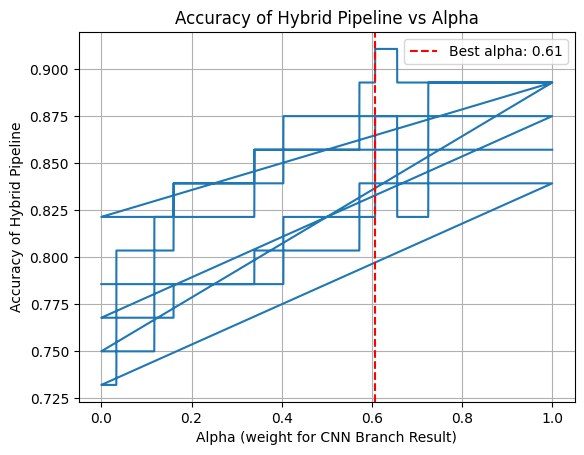

Hybrid Pipeline Report with Best Alpha for rf model:
               precision    recall  f1-score   support

  herbonauten       0.88      0.86      0.87        35
vouchervision       0.86      0.89      0.87        35

     accuracy                           0.87        70
    macro avg       0.87      0.87      0.87        70
 weighted avg       0.87      0.87      0.87        70

Hybrid Pipeline Confusion Matrix with Best Alpha for rf model:
[[30  5]
 [ 4 31]]
Determining fusion factor for lgb model...
Best alpha for lgb model: 0.6129, Best accuracy: 0.9107142857142857, Mean alpha: 0.5255380000000001


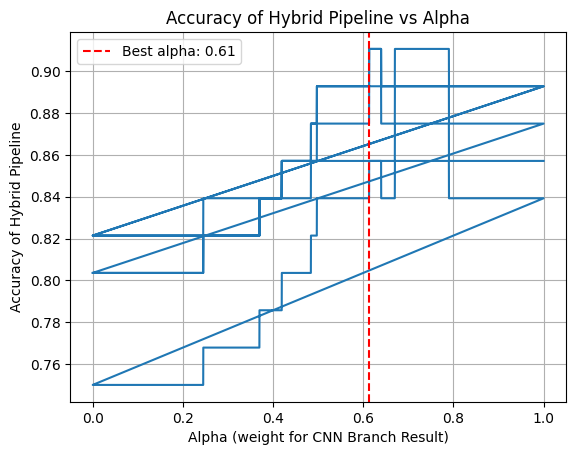

Hybrid Pipeline Report with Best Alpha for lgb model:
               precision    recall  f1-score   support

  herbonauten       0.94      0.83      0.88        35
vouchervision       0.85      0.94      0.89        35

     accuracy                           0.89        70
    macro avg       0.89      0.89      0.89        70
 weighted avg       0.89      0.89      0.89        70

Hybrid Pipeline Confusion Matrix with Best Alpha for lgb model:
[[29  6]
 [ 2 33]]
Determining fusion factor for svc model...
Best alpha for svc model: 0.6912600000000001, Best accuracy: 0.8928571428571429, Mean alpha: 0.43394200000000005


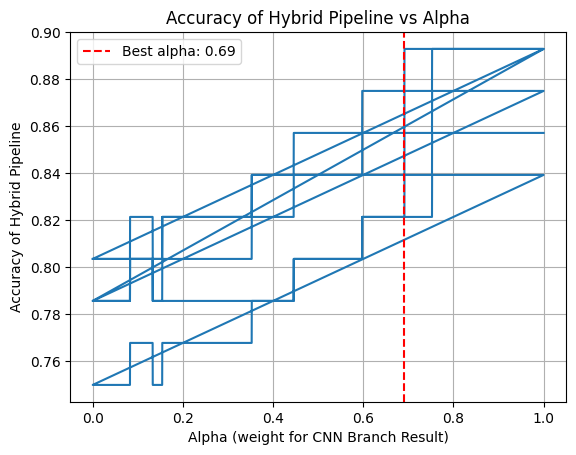

Hybrid Pipeline Report with Best Alpha for svc model:
               precision    recall  f1-score   support

  herbonauten       0.86      0.86      0.86        35
vouchervision       0.86      0.86      0.86        35

     accuracy                           0.86        70
    macro avg       0.86      0.86      0.86        70
 weighted avg       0.86      0.86      0.86        70

Hybrid Pipeline Confusion Matrix with Best Alpha for svc model:
[[30  5]
 [ 5 30]]


In [ ]:
def weighted_fusion(prob_tab, prob_cnn, alpha):
    prob_hybrid = alpha * prob_cnn + (1 - alpha) * prob_tab
    pred_hybrid = (prob_hybrid >= 0.5).astype(int)
    return pred_hybrid

def determine_fusion_factor(pred_cnn, pred_tab, alphas=0.00001, fold=5, tabular_model=None):
    alphas=np.arange(0,  1.0 + alphas, alphas)
    best_alpha = 0
    best_accuracy = 0
    alphas_plot = []
    accuracies_plot = []
    mean_alpha = 0

    kf = StratifiedKFold(n_splits=fold, shuffle=True, random_state=42) # Stratificatioin to maintain class distribution in each fold

    for train_index, _ in kf.split(predictions_df_train, predictions_df_train['best_tool_encoded']):
        train_df = predictions_df_train.iloc[train_index]
        for alpha in alphas:
            pred = weighted_fusion(train_df[f'predicted_label_pipeline_{tabular_model}_prob'], train_df['predicted_label_pipeline_cnn_prob'], alpha)
            accuracy = (pred == train_df['best_tool_encoded']).mean()
            alphas_plot.append(alpha)
            accuracies_plot.append(accuracy)
            if accuracy > best_accuracy:
                best_accuracy = accuracy
                best_alpha = alpha
                mean_alpha += alpha
    mean_alpha /= kf.get_n_splits()
    return kf, best_alpha, best_accuracy, alphas_plot, accuracies_plot, mean_alpha

def plot_fusion_results(alphas_plot, accuracies_plot, best_alpha):
    plt.plot(alphas_plot, accuracies_plot)
    plt.xlabel('Alpha (weight for CNN Branch Result)')
    plt.ylabel('Accuracy of Hybrid Pipeline')
    plt.title('Accuracy of Hybrid Pipeline vs Alpha')
    plt.axvline(x=best_alpha, color='r', linestyle='--', label=f'Best alpha: {best_alpha:.2f}')
    plt.legend()
    plt.grid()
    plt.show()

fusion_factors = dict()

for tabular_model in ['rf', 'lgb', 'svc']:
     kf, best_alpha, best_accuracy, alphas_plot, accuracies_plot, mean_alpha = determine_fusion_factor(predictions_df_train[f'predicted_label_pipeline_cnn_prob'], predictions_df_train[f'predicted_label_pipeline_{tabular_model}_prob'], alphas=0.00001, fold=5, tabular_model=tabular_model)
     fusion_factors[tabular_model] = {'best_alpha': best_alpha, 'best_accuracy': best_accuracy, 'mean_alpha': mean_alpha}
     print(f"Best alpha for {tabular_model} model: {best_alpha}, Best accuracy: {best_accuracy}, Mean alpha: {mean_alpha}")
     plot_fusion_results(alphas_plot, accuracies_plot, best_alpha)
     predictions_df_train[f'predicted_label_pipeline_hybrid_{tabular_model}'] = weighted_fusion(predictions_df_train[f'predicted_label_pipeline_{tabular_model}_prob'], predictions_df_train['predicted_label_pipeline_cnn_prob'], best_alpha)
     print("Hybrid Pipeline Report with Best Alpha for " + tabular_model + " model:")
     print(classification_report(predictions_df_train['best_tool_encoded'], predictions_df_train[f'predicted_label_pipeline_hybrid_{tabular_model}'], target_names=label_mapping.values()))
     print("Hybrid Pipeline Confusion Matrix with Best Alpha for " + tabular_model + " model:")
     print(confusion_matrix(predictions_df_train['best_tool_encoded'], predictions_df_train[f'predicted_label_pipeline_hybrid_{tabular_model}']))

In [209]:
predictions_df_val

,catalogNumber,predicted_label_pipeline_tab,predicted_label_pipeline_cnn,predicted_label_pipeline_hybrid,predicted_label_pipeline_weight_factor,predicted_label_pipeline_rf,predicted_label_pipeline_rf_prob,predicted_label_pipeline_lgb,predicted_label_pipeline_lgb_prob,predicted_label_pipeline_svc,predicted_label_pipeline_svc_prob,predicted_label_pipeline_cnn_prob,best_tool_encoded
85,B101180179,NaN,1,NaN,NaN,1,0.700228,1,0.556749,1,0.689059,0.637932,1
19,B101039505,NaN,0,NaN,NaN,0,0.239997,0,0.241627,0,0.152437,0.490327,1
170,B101128168,NaN,1,NaN,NaN,1,0.608661,1,0.821245,0,0.328483,0.684226,1
5,B100672797,NaN,0,NaN,NaN,0,0.372247,0,0.334903,0,0.328263,0.320923,0
16,B100755689,NaN,1,NaN,NaN,1,0.862917,1,0.747863,1,0.787502,0.719010,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
86,B101095559,NaN,1,NaN,NaN,1,0.797875,1,0.864278,1,0.834392,0.710365,1
80,B101213042,NaN,0,NaN,NaN,1,0.537206,0,0.483496,1,0.608230,0.381857,0
63,B109008139,NaN,0,NaN,NaN,0,0.187406,0,0.220031,0,0.167506,0.316193,0
116,B101072370,NaN,0,NaN,NaN,0,0.301011,0,0.245151,0,0.240258,0.378278,0


In [ ]:
# on validation set
def validate_hybrid_pipeline(predictions_df_val, best_alpha, tabular_model):
    predictions_df_val[f'predicted_label_pipeline_hybrid_{tabular_model}'] = weighted_fusion(predictions_df_val[f'predicted_label_pipeline_{tabular_model}_prob'], predictions_df_val['predicted_label_pipeline_cnn_prob'], best_alpha)
    print(f"Validation Set - Mean alpha for {tabular_model} model: {best_alpha}, Accuracy: {(predictions_df_val[f'predicted_label_pipeline_hybrid_{tabular_model}'] == predictions_df_val['best_tool_encoded']).mean():.4f}")
    print(f"Validation Set - Hybrid Pipeline Report with Mean Alpha for {tabular_model} model:")
    print(classification_report(predictions_df_val['best_tool_encoded'], predictions_df_val[f'predicted_label_pipeline_hybrid_{tabular_model}'], target_names=label_mapping.values()))
    print(f"Validation Set - Hybrid Pipeline Confusion Matrix with Mean Alpha for {tabular_model} model:")
    print(confusion_matrix(predictions_df_val['best_tool_encoded'], predictions_df_val[f'predicted_label_pipeline_hybrid_{tabular_model}']))
    print(f"Validation Set - {tabular_model.upper()} Pipeline Accuracy: {(predictions_df_val[f'predicted_label_pipeline_{tabular_model}'] == predictions_df_val['best_tool_encoded']).mean():.4f}")
    print(f"Validation Set - CNN Pipeline Accuracy: {(predictions_df_val['predicted_label_pipeline_cnn'] == predictions_df_val['best_tool_encoded']).mean():.4f}")
    print(f"=" * 20)

fusion_factors_csv = pd.read_csv('../../models/fusion/fusion_factor.csv').to_dict(orient='index')
fusion_factors
for tabular_model in ['rf', 'lgb', 'svc']:
    best_alpha = fusion_factors[tabular_model]['mean_alpha']
    fusion_factors_csv[0][f'fusion_factor_{tabular_model}'] = best_alpha
    validate_hybrid_pipeline(predictions_df_val, best_alpha, tabular_model)
fusion_factors_csv_df = pd.DataFrame.from_dict(fusion_factors_csv, orient='index')
fusion_factors_csv_df.to_csv('../../models/fusion/fusion_factor.csv', index=False)

KeyError: 'rf'

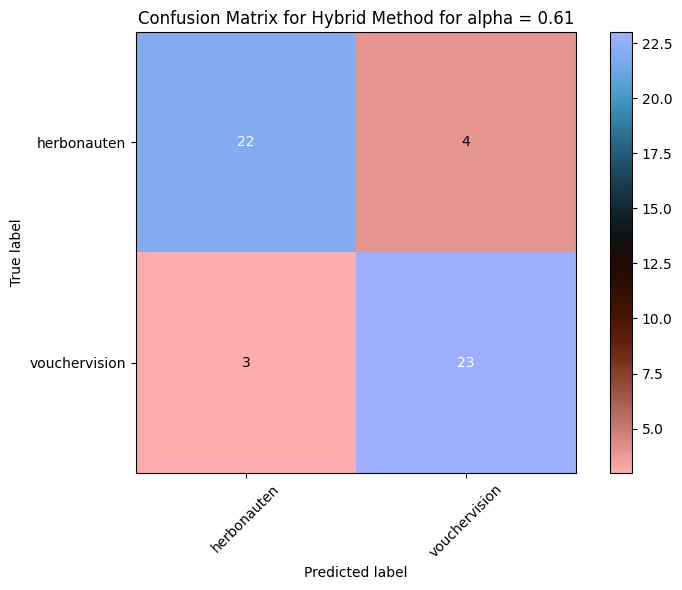

In [ ]:
plt.figure(figsize=(8, 6))
plt.imshow(cm, interpolation='nearest', cmap=plt.cm.berlin_r)
plt.title('Confusion Matrix for Hybrid Method for alpha = 0.61')
plt.colorbar()
tick_marks = np.arange(len(label_mapping))
plt.xticks(tick_marks, label_mapping.values(), rotation=45)
plt.yticks(tick_marks, label_mapping.values())
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha='center', va='center', color='white' if cm[i, j] > cm.max() / 2 else 'black')
plt.ylabel('True label')
plt.xlabel('Predicted label')
plt.tight_layout()
plt.show()